Wizualizacja 
https://www.spe.org/web/csp/datasets/set01.htm


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
path = r'/mnt/c/PINN_mgr/data_SPE/perm_case1.dat'

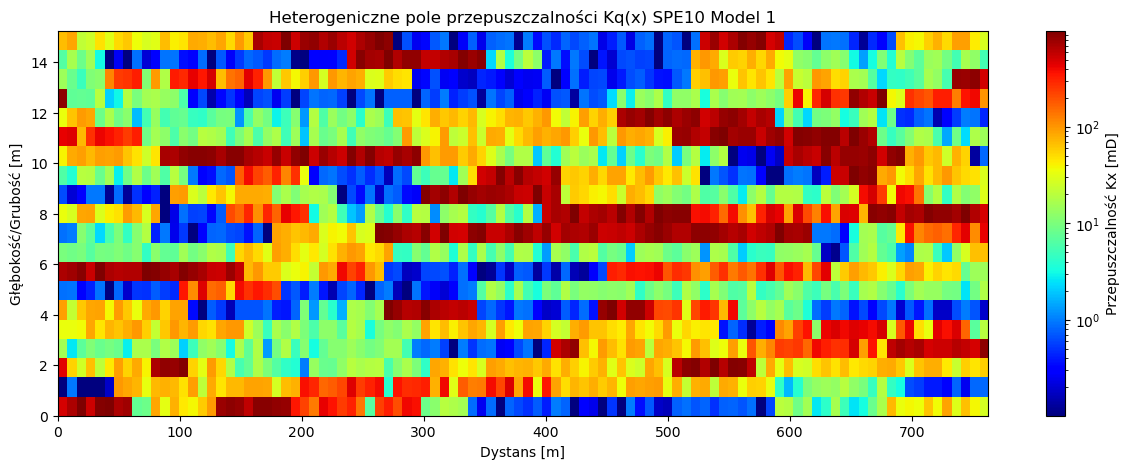

In [3]:
NX, NZ = 100, 20
LENGTH_X = 762.0 
LENGTH_Z = 15.24 

try:
    raw_data = np.loadtxt(path).flatten()
    
    # NX * NYZ = 100 * 20 = 2000
    kx_data = raw_data[0:2000]
    
    kq_matrix = kx_data.reshape((NZ, NX))
    
except Exception as e:
    print(f"Błąd {e}")
    kq_matrix = np.random.uniform(1, 100, (NZ, NX))

plt.figure(figsize=(15, 5))

img = plt.imshow(kq_matrix, 
                 cmap='jet', 
                 norm=LogNorm(vmin=kq_matrix.min()+0.1, vmax=kq_matrix.max()), 
                 extent=[0, LENGTH_X, 0, LENGTH_Z], 
                 aspect='auto',
)

plt.colorbar(img, label='Przepuszczalność Kx [mD]')
plt.title('Heterogeniczne pole przepuszczalności Kq(x) SPE10 Model 1')
plt.xlabel('Dystans [m]')
plt.ylabel('Głębokość/Grubość [m]')
plt.show()

Kolor czerwony to wysoka przepuszczalność - gaz/olej będą się szybciej przemieszczać, zaś kolor niebieski to niska przepuszczalność, napotykana jest jakaś ściana, skała.

Wymiary całkowite: 762 metry długości, 7,62 metra szerokości oraz 15,24 metra grubości.

Fine scale grid: 100 x 1 x 20 bloków o jednakowym rozmiarze.

Rozmiary pojedynczego bloku: $\Delta$ x = 7, 62 m (762 m / 100), $\Delta$ y = 7, 62 m (stała, ponieważ zakładamy, że wszystkie parametry są identyczne na całej szerokości), $\Delta$ z = 0, 762 m ( 15, 24 m / 20)

Warunki początkowe: 

- Góra modelu znajduje się na głębokości 0,0 m z ciśnieniem początkowym wynoszącym 100 psia
- Porowatość = 0,2

Właściwości płynów:

- Lepkość: ropa (μo​) = 1 cp, gaz (μg​) = 0,01 cp (stała podczas symulacji).
- Gęstość: ropa (ρo​) = 700 kg/m³, gaz (ρg​) = 1,0 kg/m³.

Właściwości skały:

- Rozkład przepuszczalności (K) jest polem generowanym geostatystycznie (skorelowanym).

Eksploatacja (Studnie):

- Zatłaczanie: Gaz jest wtłaczany przez zatłaczacz zlokalizowany po lewej stronie modelu.

- Produkcja: Ropa (dead oil) jest wydobywana przez studnię po prawej stronie modelu.

- Obie studnie mają średnicę wewnętrzną 1,0 ft i są udostępnione pionowo przez całą miąższość modelu.

- Wskaźnik zatłaczania: Ustawiony tak, aby uzyskać prędkość frontu na poziomie 0,3 m/d (ok. 6,97 m³ na dobę).

Limit produkcji: Studnia wydobywcza ma ustawione stałe graniczne ciśnienie denne (BHP) wynoszące 95 psia. Głębokość odniesienia dla ciśnienia dennego to 0,0 m (góra modelu).

Jednostki:

psia (pounds per square inch absolute): 1 psi ≈ 6894,76 Pa (0,069 bara)

cp (centipoise): 1 cp=0,001 Pa⋅s (1 mPa⋅s) -> woda w temperaturze pokojowej ma lepkość około 1 cp

ft (foot / stopa): 1 ft=0,3048 m (około 30,5 cm)

## Model 2


Plik `spe_data_model2.dat` zawiera 3 bloki Kx, Ky, Kz, każdy z nich ma 1122000 wartości. Wybieramy pierwszy blok Kx po poziomej współrzędnej. Warstwy danych od 36 do 85 to UpperNess, czyli kanały rzeczne. Wybieramy warstę np. 50. 

In [4]:
NX, NY, NZ = 60, 220, 85
PATH = r'/mnt/c/PINN_mgr/data_SPE/spe_perm_model2.dat'
ft_to_m = 0.3048

In [5]:
width_m = NX * 20 * ft_to_m   # ok. 365.76 m
height_m = NY * 10 * ft_to_m  # ok. 670.56 m

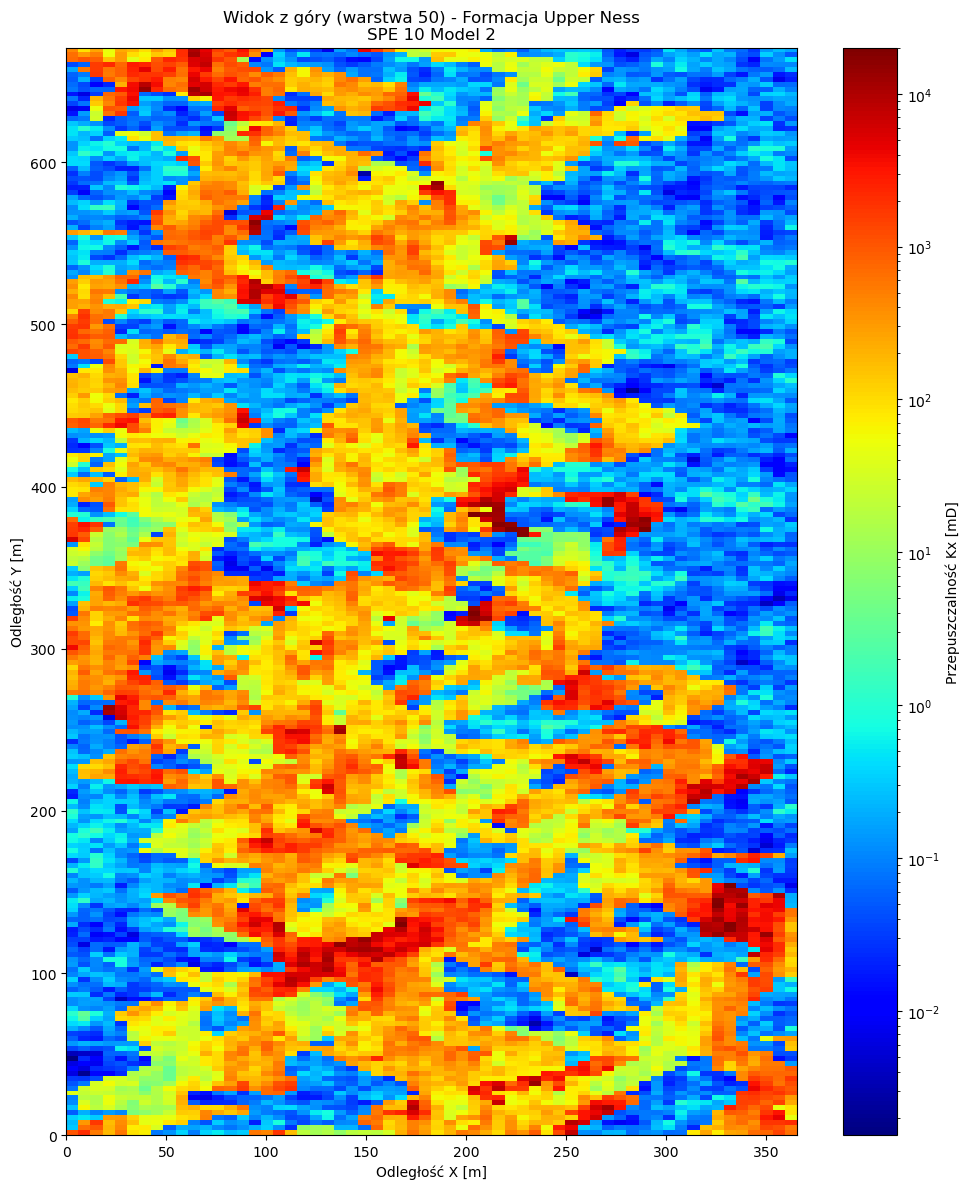

In [6]:

try:
    raw_data = np.fromfile(PATH, sep=' ') 
    
    kx_all = raw_data[0 : NX*NY*NZ]
    
    kx_3d = kx_all.reshape((NZ, NY, NX))
    
    layer_idx = 50 
    kq_slice = kx_3d[layer_idx, :, :]

    plt.figure(figsize=(10, 12)) 
    
    img = plt.imshow(kq_slice, 
                     cmap='jet', 
                     norm=LogNorm(vmin=max(kq_slice.min(), 1e-3), vmax=kq_slice.max()),
                     extent=[0, width_m, 0, height_m], 
                     origin='lower',
                     aspect='auto') 

    plt.colorbar(img, label='Przepuszczalność Kx [mD]')
    plt.title(f'Widok z góry (warstwa {layer_idx}) - Formacja Upper Ness\nSPE 10 Model 2')
    plt.xlabel('Odległość X [m]')
    plt.ylabel('Odległość Y [m]')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Wystąpił błąd: {e}")

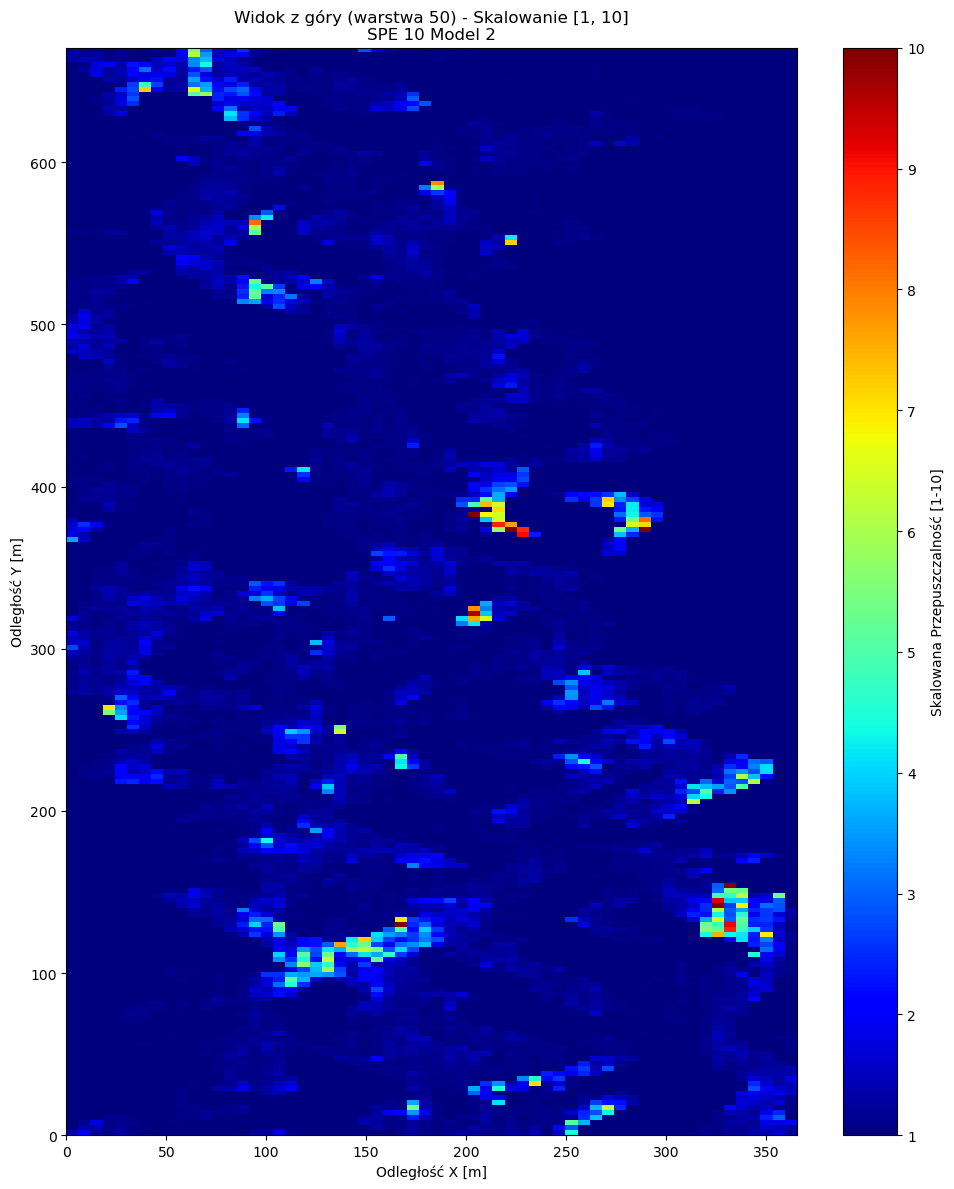

In [7]:
try:
    raw_data = np.fromfile(PATH, sep=' ') 
    
    kx_all = raw_data[0 : NX*NY*NZ]
    
    kx_3d = kx_all.reshape((NZ, NY, NX))
    
    layer_idx = 50 
    kq_slice = kx_3d[layer_idx, :, :]

    k_min, k_max = kq_slice.min(), kq_slice.max()
    kq_scaled = (kq_slice - k_min) / (k_max - k_min) * (10.0 - 1.0) + 1.0

    plt.figure(figsize=(10, 12)) 
    
    img = plt.imshow(kq_scaled, 
                     cmap='jet', 
                     extent=[0, width_m, 0, height_m], 
                     origin='lower',
                     aspect='auto')

    plt.colorbar(img, label='Skalowana Przepuszczalność [1-10]')
    plt.title(f'Widok z góry (warstwa {layer_idx}) - Skalowanie [1, 10]\nSPE 10 Model 2')
    plt.xlabel('Odległość X [m]')
    plt.ylabel('Odległość Y [m]')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Wystąpił błąd: {e}")

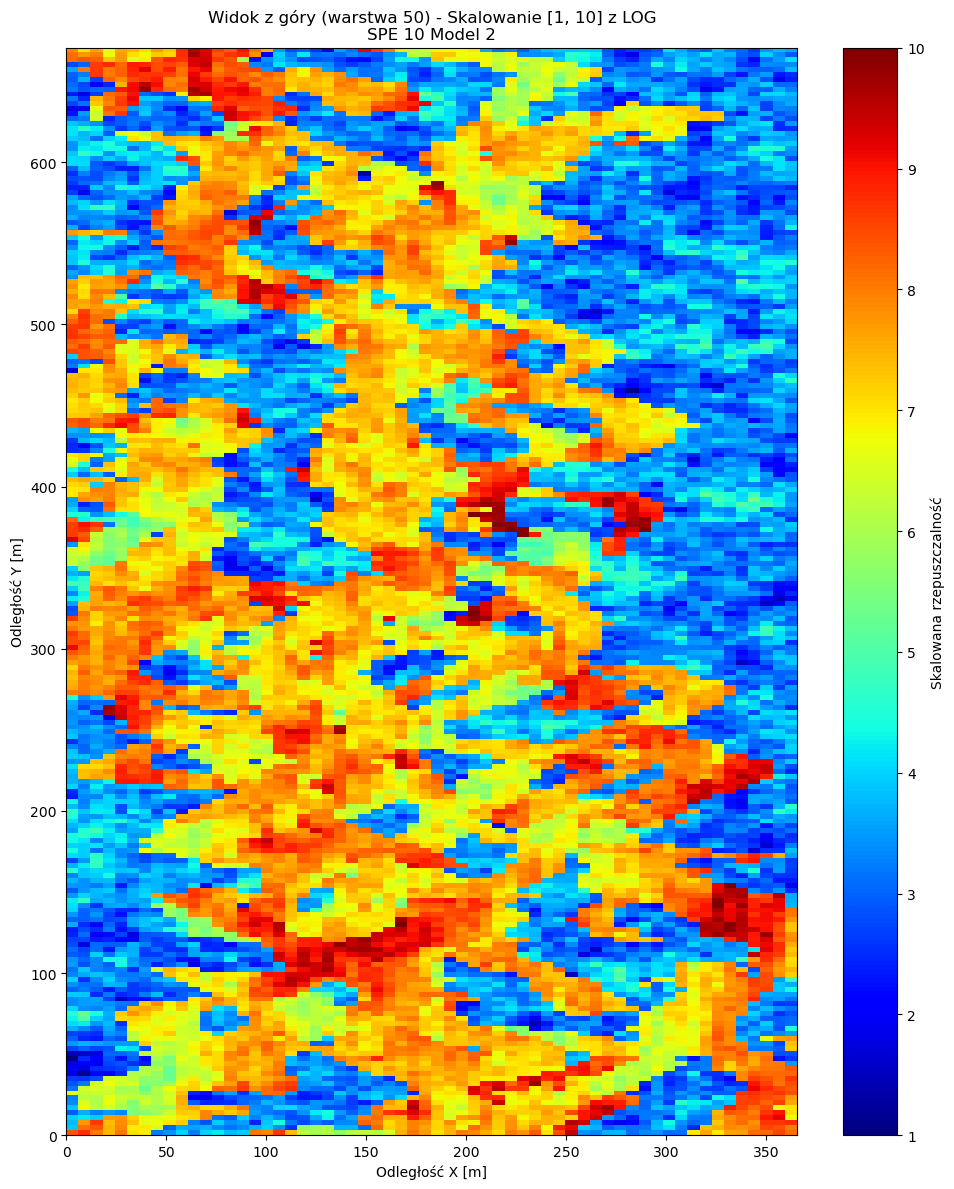

In [8]:
try:
    raw_data = np.fromfile(PATH, sep=' ') 
    
    kx_all = raw_data[0 : NX*NY*NZ]
    
    kx_3d = kx_all.reshape((NZ, NY, NX))
    
    layer_idx = 50 
    kq_slice = kx_3d[layer_idx, :, :]

    log_kq = np.log10(kq_slice + 1e-6) #dodajemy małą wartość, żeby nie było log(0)
    l_min, l_max = log_kq.min(), log_kq.max()

    kq_scaled = (log_kq - l_min) / (l_max - l_min) * (10.0 - 1.0) + 1.0

    plt.figure(figsize=(10, 12)) 
    
    img = plt.imshow(kq_scaled, 
                     cmap='jet', 
                     extent=[0, width_m, 0, height_m], 
                     origin='lower',
                     aspect='auto')

    plt.colorbar(img, label='Skalowana rzepuszczalność')
    plt.title(f'Widok z góry (warstwa {layer_idx}) - Skalowanie [1, 10] z LOG\nSPE 10 Model 2')
    plt.xlabel('Odległość X [m]')
    plt.ylabel('Odległość Y [m]')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Wystąpił błąd: {e}")